# Optimizer + projection smoke test

Trains a small MLP on a 2D Gaussian-mixture classification task with every optimizer in `src.optimizers`, both without projection and across each projector in `src.projections` (`dom` / `bulk` modes).

Two loss plots:

1. Baseline — every optimizer, no projection.
2. Projection sweep — one panel per optimizer, every (projector, mode) overlaid.

In [ ]:
import sys, os

sys.path.insert(0, os.path.abspath(".."))

import copy
import math
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F

from src.optimizers import SGD, SGDM, Adam, AdamW, Muon, MeZO, SubZero, ForwardGradient
from src.projections import RandomSubspaceProjector, HessianEigenspaceProjector

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

## Dataset
Two-Gaussian mixture in 2D, 2 classes.

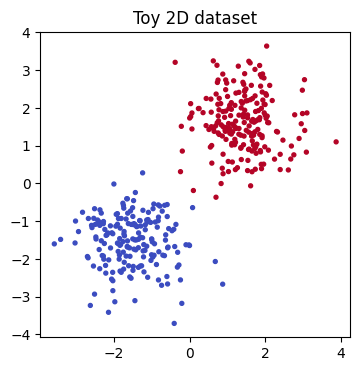

In [ ]:
def make_data(n=400, seed=0):
    g = torch.Generator().manual_seed(seed)
    centers = torch.tensor([[-1.5, -1.5], [1.5, 1.5]])
    y = torch.randint(0, 2, (n,), generator=g)
    X = centers[y] + 0.7 * torch.randn(n, 2, generator=g)
    return X, y


X, y = make_data()

plt.figure(figsize=(4, 4))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", s=8)
plt.title("Toy 2D dataset")
plt.gca().set_aspect("equal")
plt.show()

## Model

In [ ]:
def make_model(seed=SEED):
    g = torch.Generator().manual_seed(seed)
    model = torch.nn.Sequential(
        torch.nn.Linear(2, 16),
        torch.nn.ReLU(),
        torch.nn.Linear(16, 16),
        torch.nn.ReLU(),
        torch.nn.Linear(16, 2),
    )
    for p in model.parameters():
        if p.ndim >= 2:
            torch.nn.init.kaiming_uniform_(p, a=math.sqrt(5), generator=g)
        else:
            p.data.zero_()
    return model


n_params = sum(p.numel() for p in make_model().parameters())
print(f"Model has {n_params} parameters")

Model has 354 parameters


## Training helpers

In [ ]:
def sample_batch(X, y, bs, gen):
    idx = torch.randint(0, len(X), (bs,), generator=gen)
    return X[idx], y[idx]


def train_first_order(
    opt, model, X, y, steps, bs, projector=None, projection="none", seed=0
):
    gen = torch.Generator().manual_seed(seed)
    losses = []
    for _ in range(steps):
        xb, yb = sample_batch(X, y, bs, gen)
        opt.zero_grad()
        loss = F.cross_entropy(model(xb), yb)
        loss.backward()
        opt.step(projector=projector, projection=projection)
        losses.append(loss.item())
    return losses


def train_mezo(
    model, X, y, steps, bs, lr=1e-3, eps=1e-2, projector=None, projection="none", seed=0
):
    opt = MeZO(model.parameters(), lr=lr, eps=eps, seed=seed)
    gen = torch.Generator().manual_seed(seed + 1)
    losses = []
    holder = {}

    def closure():
        return F.cross_entropy(model(holder["xb"]), holder["yb"])

    for _ in range(steps):
        holder["xb"], holder["yb"] = sample_batch(X, y, bs, gen)
        loss = opt.step(closure, projector=projector, projection=projection)
        losses.append(float(loss))
    return losses


def train_subzero(
    model,
    X,
    y,
    steps,
    bs,
    lr=1e-3,
    eps=1e-2,
    rank=4,
    update_freq=20,
    projector=None,
    projection="none",
    seed=0,
):
    opt = SubZero(
        model.parameters(),
        lr=lr,
        eps=eps,
        rank=rank,
        update_freq=update_freq,
        seed=seed,
    )
    gen = torch.Generator().manual_seed(seed + 3)
    losses = []
    holder = {}

    def closure():
        return F.cross_entropy(model(holder["xb"]), holder["yb"])

    for _ in range(steps):
        holder["xb"], holder["yb"] = sample_batch(X, y, bs, gen)
        loss = opt.step(closure, projector=projector, projection=projection)
        losses.append(float(loss))
    return losses


def train_fgd(
    model, X, y, steps, bs, lr=5e-3, projector=None, projection="none", seed=0
):
    base = copy.deepcopy(model).to("meta")
    names = list(dict(model.named_parameters()).keys())
    buffers = dict(model.named_buffers())
    opt = ForwardGradient(model.parameters(), lr=lr)
    gen = torch.Generator().manual_seed(seed + 2)
    losses = []
    holder = {}

    def closure(params):
        out = torch.func.functional_call(
            base, ({k: v for k, v in zip(names, params)}, buffers), (holder["xb"],)
        )
        return F.cross_entropy(out, holder["yb"])

    for _ in range(steps):
        holder["xb"], holder["yb"] = sample_batch(X, y, bs, gen)
        loss = opt.step(closure, projector=projector, projection=projection)
        losses.append(float(loss))
    return losses


def smooth(xs, k=15):
    xs = np.asarray(xs)
    if len(xs) < k:
        return xs
    return np.convolve(xs, np.ones(k) / k, mode="valid")

## Unified runner

In [ ]:
STEPS = 300
BATCH = 32

OPT_CONFIG = {
    "SGD": ((SGD, {"lr": 1e-2}), "first"),
    "SGDM": ((SGDM, {"lr": 5e-3, "momentum": 0.9}), "first"),
    "Adam": ((Adam, {"lr": 5e-3}), "first"),
    "AdamW": ((AdamW, {"lr": 5e-3}), "first"),
    "Muon": ((Muon, {"lr": 2e-2, "weight_decay": 0.0}), "first"),
    "MeZO": ((None, {"lr": 1e-3, "eps": 1e-2}), "mezo"),
    "SubZero": (
        (None, {"lr": 1e-3, "eps": 1e-2, "rank": 4, "update_freq": 20}),
        "subzero",
    ),
    "FGD": ((None, {"lr": 5e-3}), "fgd"),
}


def run_optimizer(name, projector_factory=None, projection="none"):
    (cls, kwargs), kind = OPT_CONFIG[name]
    model = make_model()
    proj = projector_factory(model) if projector_factory is not None else None
    if kind == "first":
        opt = cls(model.parameters(), **kwargs)
        return train_first_order(
            opt, model, X, y, STEPS, BATCH, projector=proj, projection=projection
        )
    if kind == "mezo":
        return train_mezo(
            model, X, y, STEPS, BATCH, projector=proj, projection=projection, **kwargs
        )
    if kind == "subzero":
        return train_subzero(
            model, X, y, STEPS, BATCH, projector=proj, projection=projection, **kwargs
        )
    if kind == "fgd":
        return train_fgd(
            model, X, y, STEPS, BATCH, projector=proj, projection=projection, **kwargs
        )
    raise ValueError(kind)


## 1. Baseline — every optimizer, no projection

In [ ]:
OPTIMIZERS = list(OPT_CONFIG.keys())
baseline = {name: run_optimizer(name) for name in OPTIMIZERS}

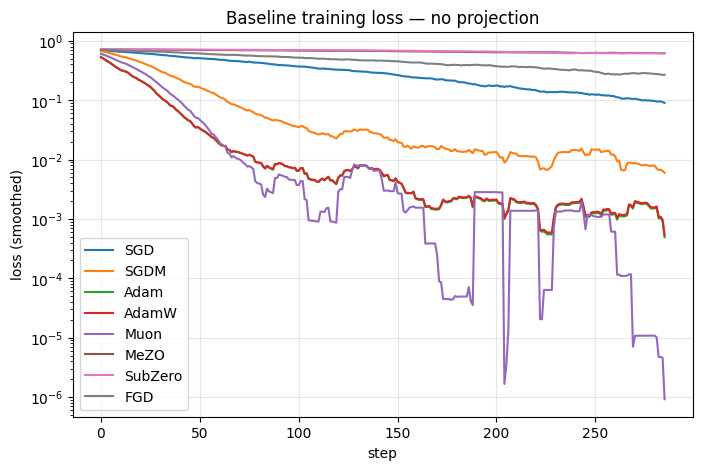

In [ ]:
plt.figure(figsize=(8, 5))
for name, losses in baseline.items():
    plt.plot(smooth(losses), label=name)
plt.yscale("log")
plt.xlabel("step")
plt.ylabel("loss (smoothed)")
plt.title("Baseline training loss — no projection")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 2. Projection sweep

- `random` — `RandomSubspaceProjector` with k = 50 directions
- `hessian` — `HessianEigenspaceProjector` with k = 20, basis built from the full dataset at the initial weights

Each projector is rebuilt against a freshly initialised model (so projector and optimizer share the same parameter tensors).

In [ ]:
K_RANDOM = 50
K_HESSIAN = 20


def make_random_proj(model):
    proj = RandomSubspaceProjector(model.parameters(), k=K_RANDOM, seed=SEED)
    proj.update_basis()
    return proj


def make_hessian_proj(model):
    proj = HessianEigenspaceProjector(
        model.parameters(), k=K_HESSIAN, solver="eigsh", tol=1e-3
    )

    def closure():
        return F.cross_entropy(model(X), y)

    proj.update_basis(closure)
    return proj


PROJECTORS = {"random": make_random_proj, "hessian": make_hessian_proj}
MODES = ["dom", "bulk"]

In [ ]:
results = {name: {"none": baseline[name]} for name in OPTIMIZERS}

for opt_name in OPTIMIZERS:
    for proj_name, proj_factory in PROJECTORS.items():
        for mode in MODES:
            key = f"{proj_name}-{mode}"
            print(f"Running {opt_name:>5s} / {key} ...")
            results[opt_name][key] = run_optimizer(opt_name, proj_factory, mode)

Running   SGD / random-dom ...
Running   SGD / random-bulk ...
Running   SGD / hessian-dom ...
Running   SGD / hessian-bulk ...
Running  SGDM / random-dom ...
Running  SGDM / random-bulk ...
Running  SGDM / hessian-dom ...
Running  SGDM / hessian-bulk ...
Running  Adam / random-dom ...
Running  Adam / random-bulk ...
Running  Adam / hessian-dom ...
Running  Adam / hessian-bulk ...
Running AdamW / random-dom ...
Running AdamW / random-bulk ...
Running AdamW / hessian-dom ...
Running AdamW / hessian-bulk ...
Running  Muon / random-dom ...
Running  Muon / random-bulk ...
Running  Muon / hessian-dom ...
Running  Muon / hessian-bulk ...
Running  MeZO / random-dom ...
Running  MeZO / random-bulk ...
Running  MeZO / hessian-dom ...
Running  MeZO / hessian-bulk ...
Running SubZero / random-dom ...
Running SubZero / random-bulk ...
Running SubZero / hessian-dom ...
Running SubZero / hessian-bulk ...
Running   FGD / random-dom ...
Running   FGD / random-bulk ...
Running   FGD / hessian-dom ...
R

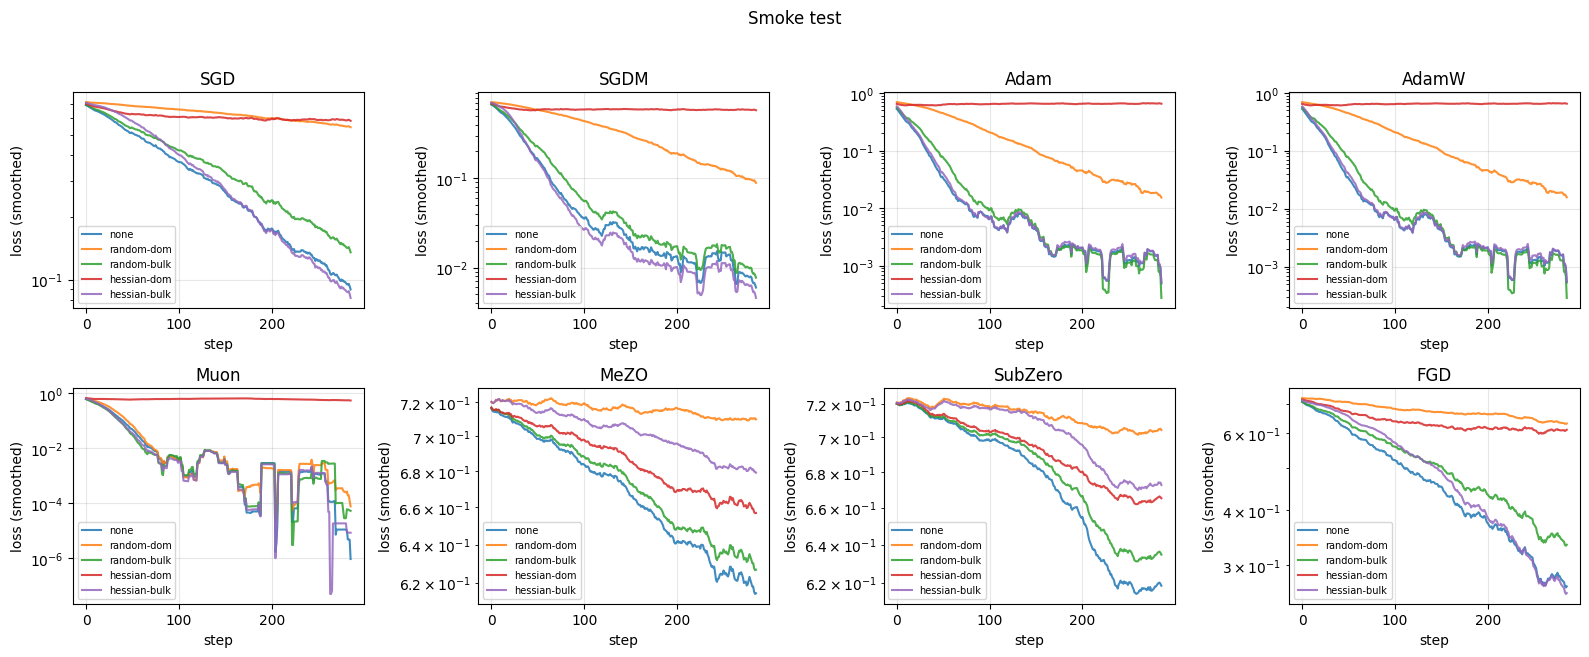

In [ ]:
ncols = 4
nrows = math.ceil(len(OPTIMIZERS) / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3.2 * nrows), sharey=False)
axes = np.array(axes).flatten()

for ax, opt_name in zip(axes, OPTIMIZERS):
    for key, losses in results[opt_name].items():
        ax.plot(smooth(losses), label=key, alpha=0.85)
    ax.set_title(opt_name)
    ax.set_yscale("log")
    ax.set_xlabel("step")
    ax.set_ylabel("loss (smoothed)")
    ax.grid(alpha=0.3)
    ax.legend(fontsize=7, loc="best")

for ax in axes[len(OPTIMIZERS) :]:
    ax.axis("off")

fig.suptitle("Smoke test", y=1.02)
plt.tight_layout()
plt.show()

In [12]:
fig.savefig("projection_sweep.png", dpi=150, bbox_inches="tight")